In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels
from sklearn.preprocessing import StandardScaler

In [71]:
#Connecting to the database to extract the data
import psycopg2
import pandas as pd

# Database connection details
db_params = {
    "host": "172.178.131.221",
    "port": 5432,
    "dbname": "postgres",
    "user": "luxds",
    "password": "1234"
}

try:
    # Connect to PostgreSQL
    conn = psycopg2.connect(**db_params)

    # Use pandas to fetch table names
    tables_query = "SELECT table_schema, table_name FROM information_schema.tables ORDER BY table_schema, table_name;"
    df_tables = pd.read_sql(tables_query, conn)
    print(f"Available tables /n {df_tables}")

    #Fetching train data
    df_train = pd.read_sql("SELECT * FROM ds.traindata;", conn)
    df_train.to_csv("train_data.csv", index = False)

    #Fetching test data
    df_test = pd.read_sql("SELECT * FROM ds.testdata;", conn)
    df_test.to_csv("test_data.csv", index = False)

    # Close connection
    conn.close()

except Exception as e:
    print("Error:", e)


C:\Users\Admin\AppData\Local\Temp\ipykernel_26096\3676379552.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(tables_query, conn)


Available tables /n            table_schema                 table_name
0                    ds                   testdata
1                    ds                  traindata
2    information_schema  _pg_foreign_data_wrappers
3    information_schema        _pg_foreign_servers
4    information_schema  _pg_foreign_table_columns
..                  ...                        ...
209          pg_catalog            pg_user_mapping
210          pg_catalog           pg_user_mappings
211          pg_catalog                   pg_views
212          pg_catalog             pg_wait_events
213              public                 btc_prices

[214 rows x 2 columns]


C:\Users\Admin\AppData\Local\Temp\ipykernel_26096\3676379552.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_train = pd.read_sql("SELECT * FROM ds.traindata;", conn)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26096\3676379552.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT * FROM ds.testdata;", conn)


In [72]:
df_train = pd.read_csv('train_data.csv')
df_train.head()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score
0,810,107410.0,11924.0,48,7.97,43.29,32,27181.0,58,7634.543366
1,418,37482.0,19291.0,24,6.94,11.01,33,15089.0,43,6249.833059
2,724,85641.0,39501.0,36,8.59,37.11,0,97459.0,33,2148.117990
3,444,73331.0,25714.0,36,13.09,33.39,18,2413.0,48,4979.385344
4,440,46723.0,35651.0,36,8.30,46.21,6,9716.0,42,2993.851950


In [73]:
df_ln_train = df_train.copy()

In [74]:
df_ln_train.columns

Index(['credit_score', 'income', 'loan_amount', 'loan_term', 'interest_rate',
       'debt_to_income_ratio', 'employment_years', 'savings_balance', 'age',
       'default_risk_score'],
      dtype='object')

In [75]:
df_test = pd.read_csv('test_data.csv')
df_test.head()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score
0,340,31745.0,8983.0,48,10.12,18.33,11,91417.0,56,8342.948454
1,439,115081.0,42051.0,60,3.33,31.77,6,17127.0,51,1710.293506
2,619,35313.0,6619.0,36,9.06,24.29,20,46761.0,42,8744.629774
3,664,72269.0,19226.0,48,4.29,12.50,26,64340.0,36,6191.771456
4,564,46292.0,30476.0,48,11.15,40.55,20,93831.0,50,3990.722206


In [76]:
df_test.shape

(200, 10)

In [77]:
df_train.shape

(800, 10)

In [78]:
df_train.dtypes

credit_score              int64
income                  float64
loan_amount             float64
loan_term                 int64
interest_rate           float64
debt_to_income_ratio    float64
employment_years          int64
savings_balance         float64
age                       int64
default_risk_score      float64
dtype: object

In [79]:
df_train.isna().sum()

credit_score            0
income                  0
loan_amount             0
loan_term               0
interest_rate           0
debt_to_income_ratio    0
employment_years        0
savings_balance         0
age                     0
default_risk_score      0
dtype: int64

In [80]:
df_train.duplicated().sum()

0

In [81]:
df_train.describe()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,565.405000,85779.287500,27795.651250,36.315000,8.732238,29.812500,16.376250,48850.921250,42.443750,4529.968687
std,159.528109,37972.705711,12819.525021,17.163012,3.670453,11.626346,10.036339,29785.455545,15.011446,2567.048232
min,300.000000,20060.000000,5097.000000,12.000000,2.510000,10.000000,0.000000,28.000000,18.000000,49.757940
25%,426.750000,53056.250000,16136.000000,24.000000,5.537500,19.925000,8.000000,21359.750000,29.000000,2377.592064
50%,553.000000,85105.000000,28518.500000,36.000000,8.725000,29.645000,16.000000,47314.500000,42.000000,4379.666025
75%,702.000000,118776.000000,38539.750000,48.000000,11.915000,40.005000,25.000000,76191.000000,55.250000,6821.026905
max,849.000000,149972.000000,49976.000000,60.000000,14.990000,49.910000,34.000000,99976.000000,69.000000,9113.843128


In [82]:
df_train.columns

Index(['credit_score', 'income', 'loan_amount', 'loan_term', 'interest_rate',
       'debt_to_income_ratio', 'employment_years', 'savings_balance', 'age',
       'default_risk_score'],
      dtype='object')

In [83]:
#Filtering the columns based on std value to plot boxplots
std_values = df_train.describe().loc['std']
high_std_cols = std_values[std_values > 100].index
low_std_cols = std_values[std_values <= 100].index


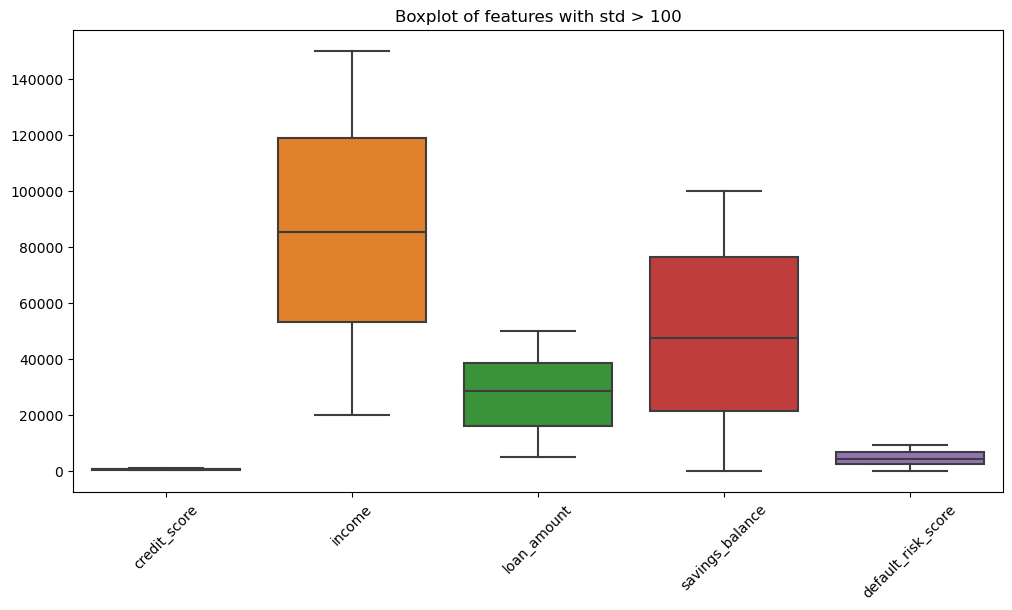

In [84]:
#Plotting columns with higher std
plt.figure(figsize=(12,6))
sns.boxplot(data=df_train[high_std_cols])
plt.title('Boxplot of features with std > 100')
plt.xticks(rotation=45)
plt.show()

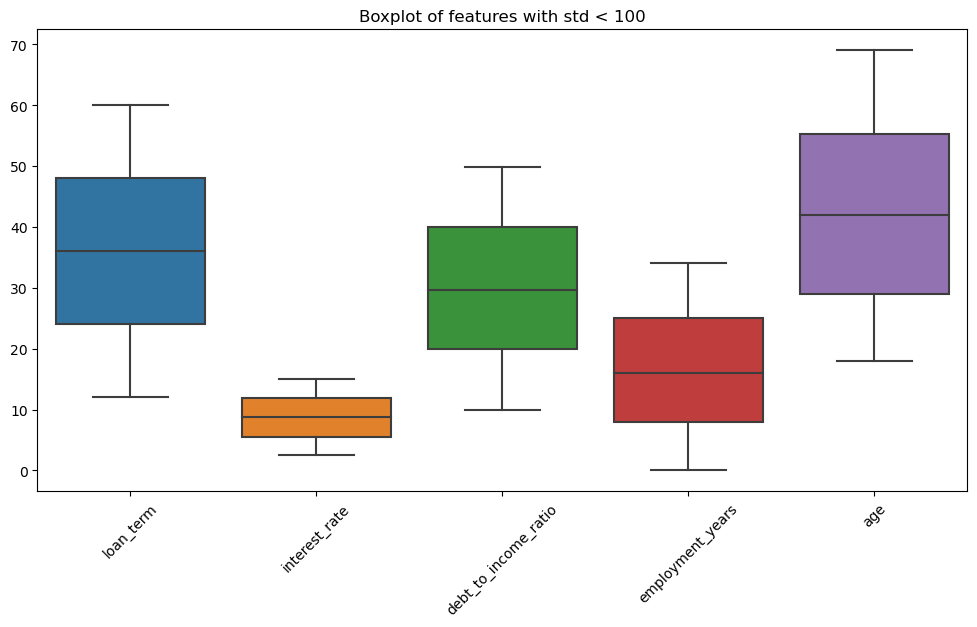

In [85]:
#Plotting columns with stds < 100
plt.figure(figsize=(12,6))
sns.boxplot(data=df_train[low_std_cols])
plt.title('Boxplot of features with std < 100')
plt.xticks(rotation=45)
plt.show()

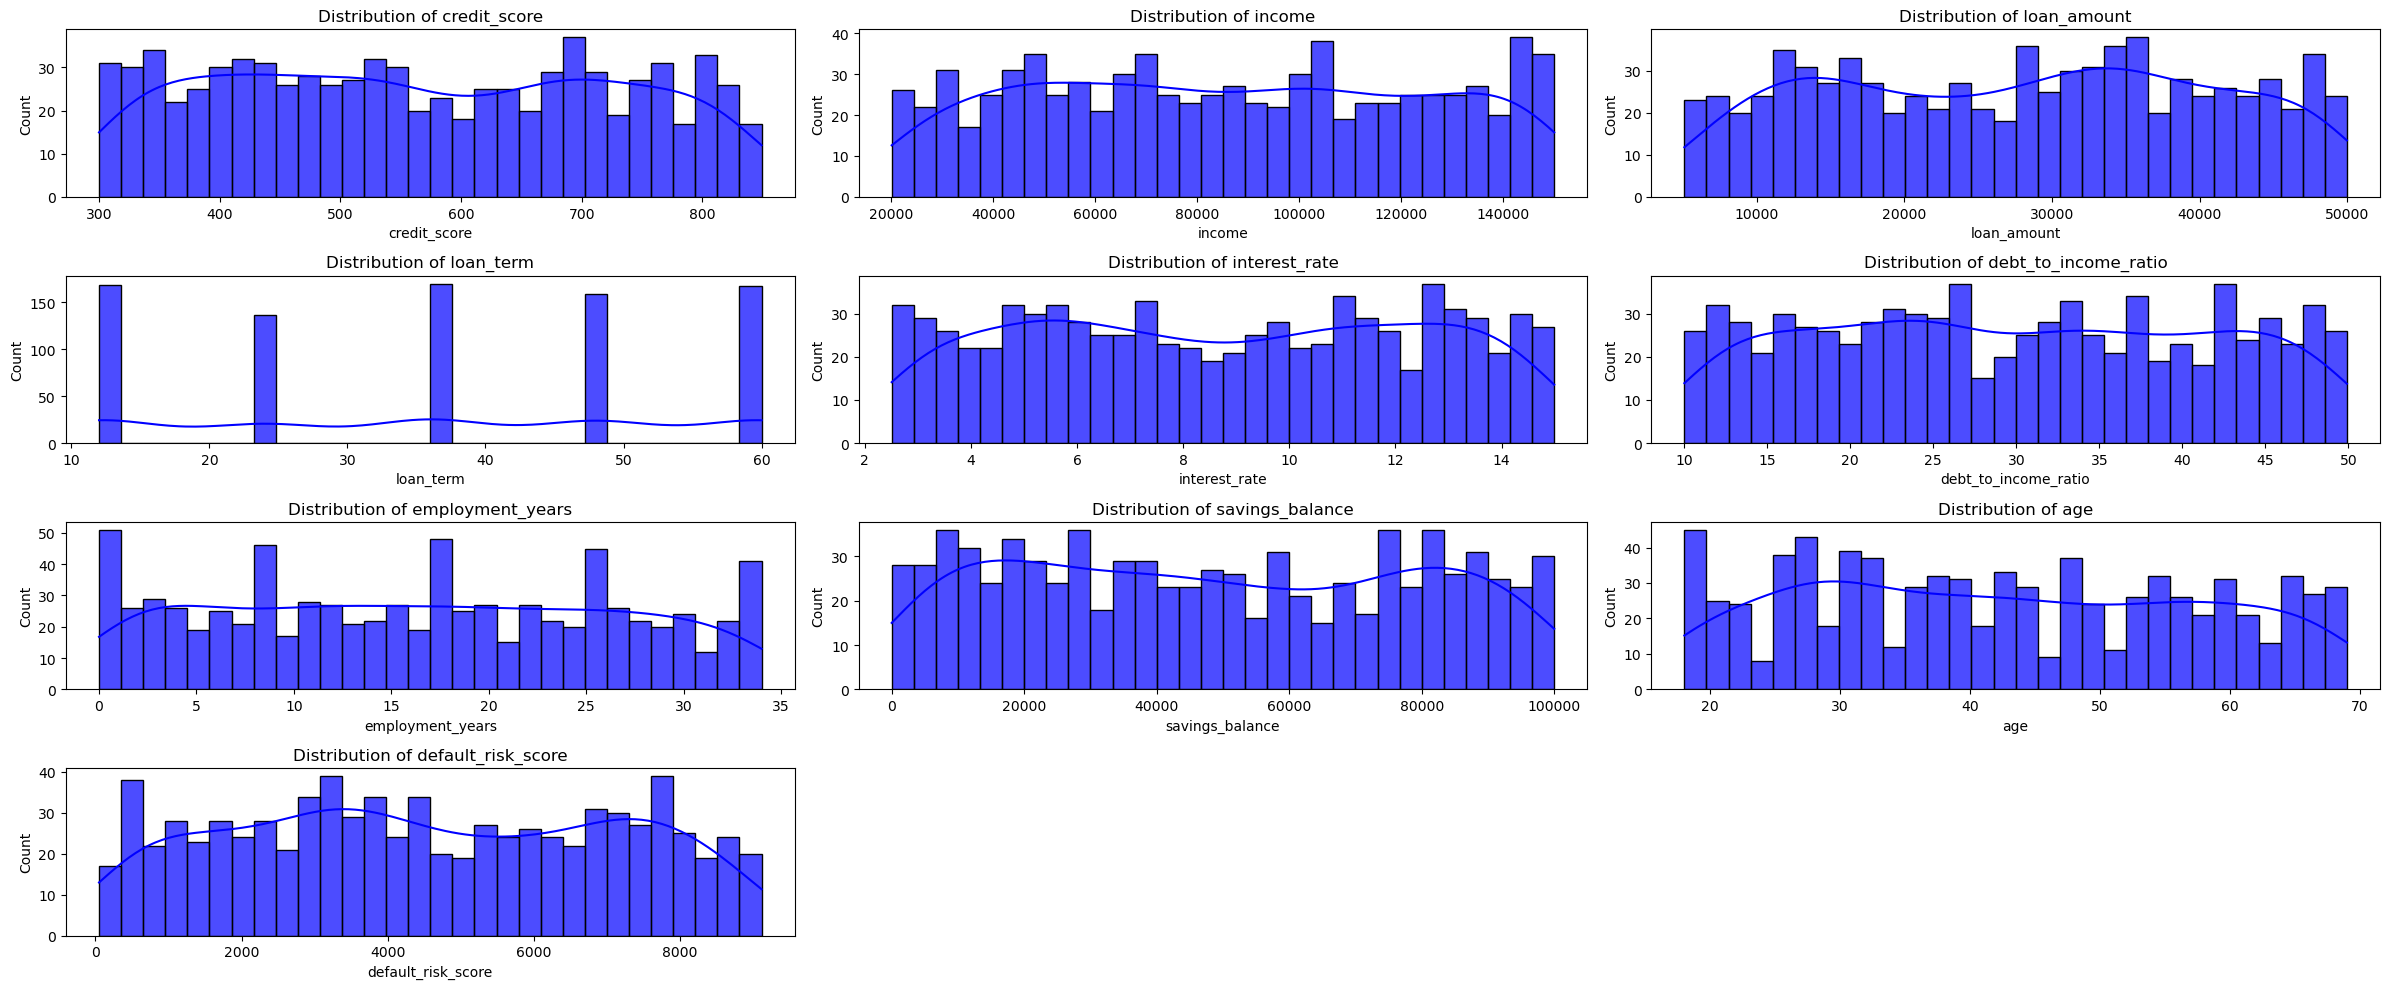

In [86]:
#Plotting histograms for all numerical columns
plt.figure(figsize=(24, 10))
for i,col in enumerate(df_train.columns):
    if col == 'credit_score_category': continue
    plt.subplot(4,3, i+1)
    sns.histplot(df_train[col], bins=30, kde=True, alpha=0.7, edgecolor='black', color='blue')  
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


Most of the variables are uniformly distributed. Hence it explains why there are no outliers because all values are equally probable.

* Some boxplots had single lines, those features had low variance or very different scales (e.g., credit_score ranges 300-800, while income could be thousands).


In [87]:
#Engineering a new feature 
df_train['loan_to_income'] = df_train['loan_amount'] / df_train['income']
df_train['credit_score_category'] = pd.qcut(df_train['credit_score'], q=4, labels=["Low", "Medium", "High", "Very High"])

In [88]:
df_train['credit_score_category'].value_counts()

credit_score_category
Medium       202
Low          200
High         199
Very High    199
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_26096\3237560780.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df_train['credit_score_category'], y=df_train['default_risk_score'], palette='coolwarm', ci=None)


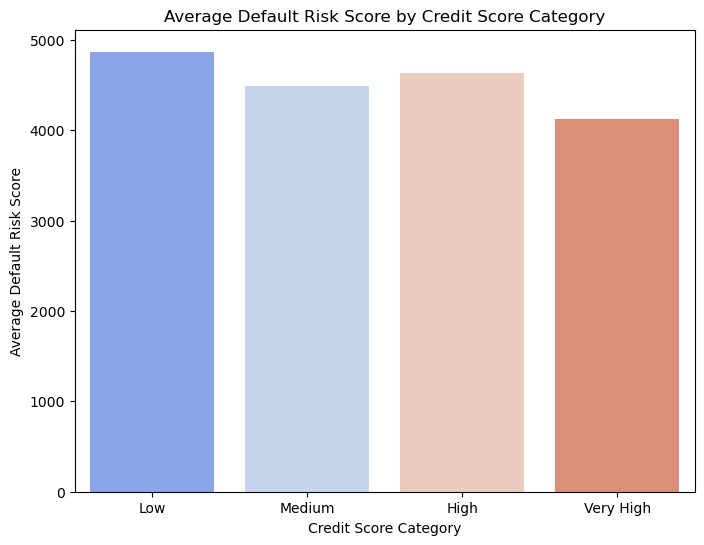

In [89]:
#Average default risk per credit score category
plt.figure(figsize=(8,6))
sns.barplot(x=df_train['credit_score_category'], y=df_train['default_risk_score'], palette='coolwarm', ci=None)
plt.xlabel('Credit Score Category')
plt.ylabel('Average Default Risk Score')
plt.title('Average Default Risk Score by Credit Score Category')
plt.show()

Borrowers with poor credit scores have highest default risks. They are less reliable in paying loans.
Borrowers with very hight credit scores are have the lowest default scores. 
Business decision:
Higher risk groups might need higher interst rates or stricter approval requirements.

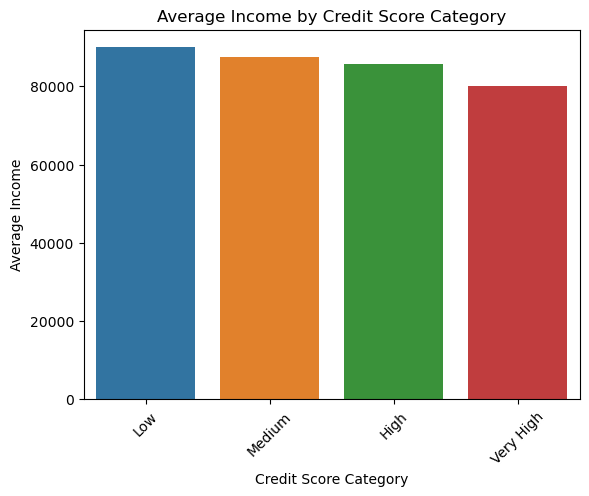

In [90]:
#Average income by credit score category
avg_income = df_train.groupby('credit_score_category')['income'].mean()
sns.barplot(x=avg_income.index, y=avg_income.values)
plt.xlabel("Credit Score Category")
plt.ylabel("Average Income")
plt.title("Average Income by Credit Score Category")
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

Normally, people with higher credit scores tend to have higher incomes.
Here, lower credit score groups have higher average incomes than those with very high credit scores.
This could suggest that income alone isnt the main factor influencing credit score—other financial factors could have higher influence.

In [91]:
#Age groups - new feature
df_train['age_group'] = pd.qcut(df_train['age'], q=4, labels=['Young adults', 'Middle aged', 'Pre retirement','Retirees'])

In [92]:
#Loan burden - new feature
df_train['loan_burden'] = df_train['loan_amount'] / (df_train['income'] + df_train['savings_balance'])

In [93]:
df_train.columns

Index(['credit_score', 'income', 'loan_amount', 'loan_term', 'interest_rate',
       'debt_to_income_ratio', 'employment_years', 'savings_balance', 'age',
       'default_risk_score', 'loan_to_income', 'credit_score_category',
       'age_group', 'loan_burden'],
      dtype='object')

In [94]:
df_train['age_group'].value_counts()

age_group
Middle aged       215
Young adults      201
Retirees          200
Pre retirement    184
Name: count, dtype: int64

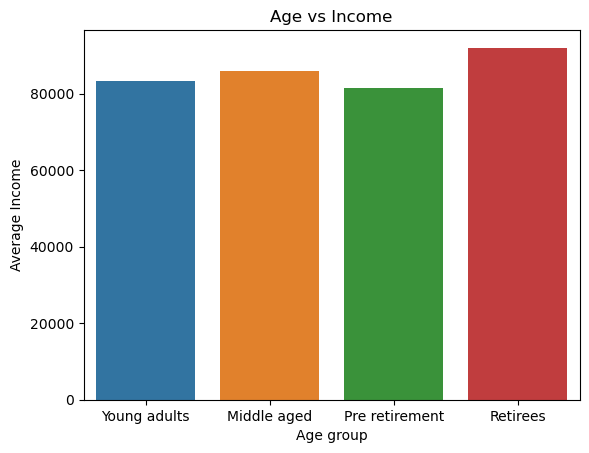

In [95]:
#Plotting age group vs average income
avg_age_income = df_train.groupby('age_group')['income'].mean()
sns.barplot(x=avg_age_income.index, y=avg_age_income.values)
plt.xlabel('Age group')
plt.ylabel('Average Income')
plt.title("Age vs Income")
plt.show()

Retirees have the highest income, older individuals have accumulated wealth overitme
Middle aged adults earn more the young adults and pre-retirees, they are at the peak of their careers, attributed to promotions, job stabilit
Pre-retirees, see an income dip, due to more responsibilities(families), career stagnation, shifting to lower stress jobs.
Young adults are just starting their careers, lower paying jobs.

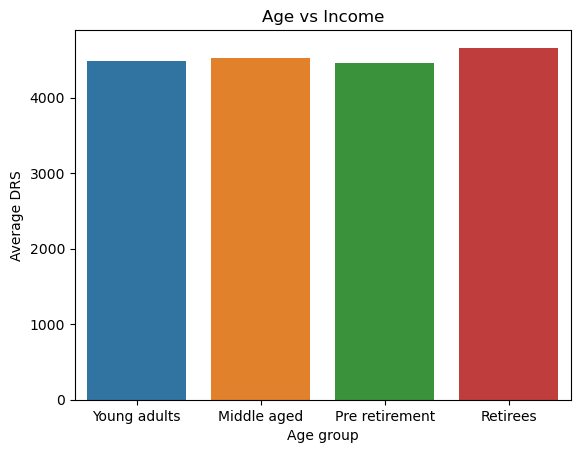

In [96]:
#Plotting age group vs default risk score
avg_age_drs = df_train.groupby('age_group')['default_risk_score'].mean()

sns.barplot(x=avg_age_drs.index, y=avg_age_drs.values)
plt.xlabel('Age group')
plt.ylabel('Average DRS')
plt.title("Age vs Income")
plt.show()

Retirees Have the Highest Default Risk Score (4,658.90)

Despite having the highest average income, retirees also have the highest default risk.
Possible reasons:
Fixed income sources (pensions, savings) may not be enough to cover debts.
Medical expenses or other financial burdens could increase default risk.

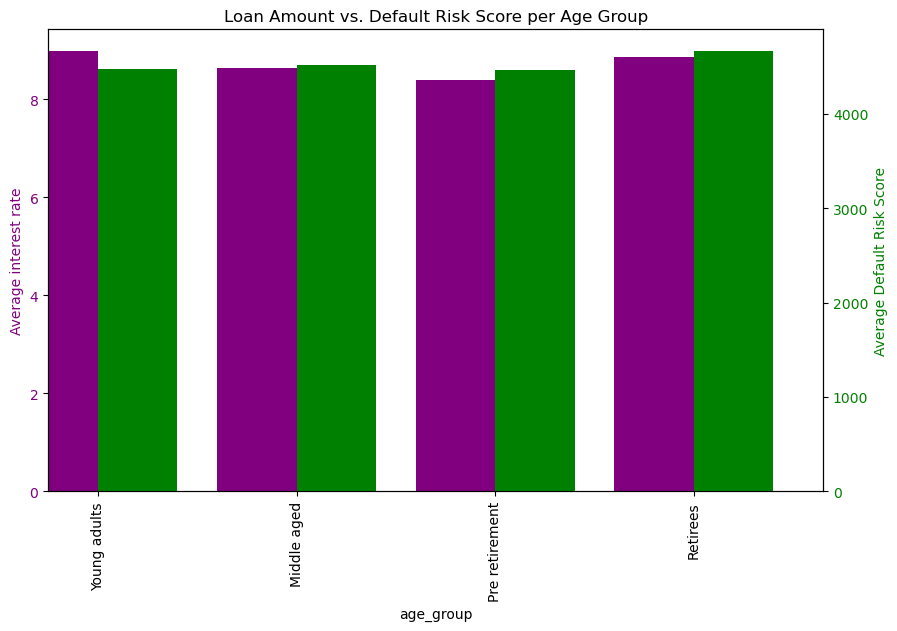

In [97]:

# Grouping by Age Groups and calculating mean Loan Amount and Default Risk Score
age_loan_default = df_train.groupby("age_group")[["interest_rate", "default_risk_score"]].mean()

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Loan Amount
color1 = "purple"
ax1.set_xlabel("Age Groups")
ax1.set_ylabel("Average interest rate", color=color1)
age_loan_default["interest_rate"].plot(kind="bar", ax=ax1, color=color1, position=1, width=0.4)
ax1.tick_params(axis="y", labelcolor=color1)

# Creating a second y-axis for Default Risk Score
ax2 = ax1.twinx()
color2 = "green"
ax2.set_ylabel("Average Default Risk Score", color=color2)
age_loan_default["default_risk_score"].plot(kind="bar", ax=ax2, color=color2, position=0, width=0.4)
ax2.tick_params(axis="y", labelcolor=color2)

# Title and layout adjustments
plt.title("Loan Amount vs. Default Risk Score per Age Group")
plt.xticks(rotation=0)
plt.show()


Retirees face a **higher default risk** due to reduced income, limited earning potential, and high expenses. Since they rely on pensions or savings rather than stable salaries, they may struggle with loan repayments. **Lenders charge them higher interest rates (8.88%)** to compensate for this risk, ensuring they recover potential losses from defaults.

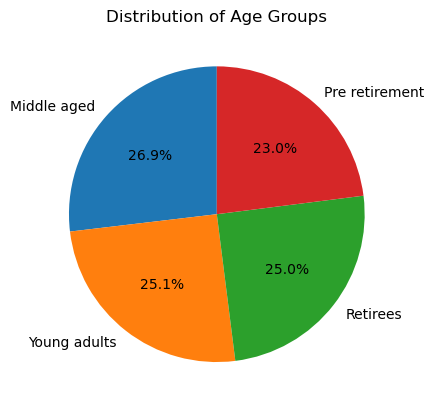

In [98]:
# Proportion of age 
age_group_counts = df_train['age_group'].value_counts()
plt.pie(age_group_counts.values, labels=age_group_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Age Groups")
plt.show()


<Axes: >

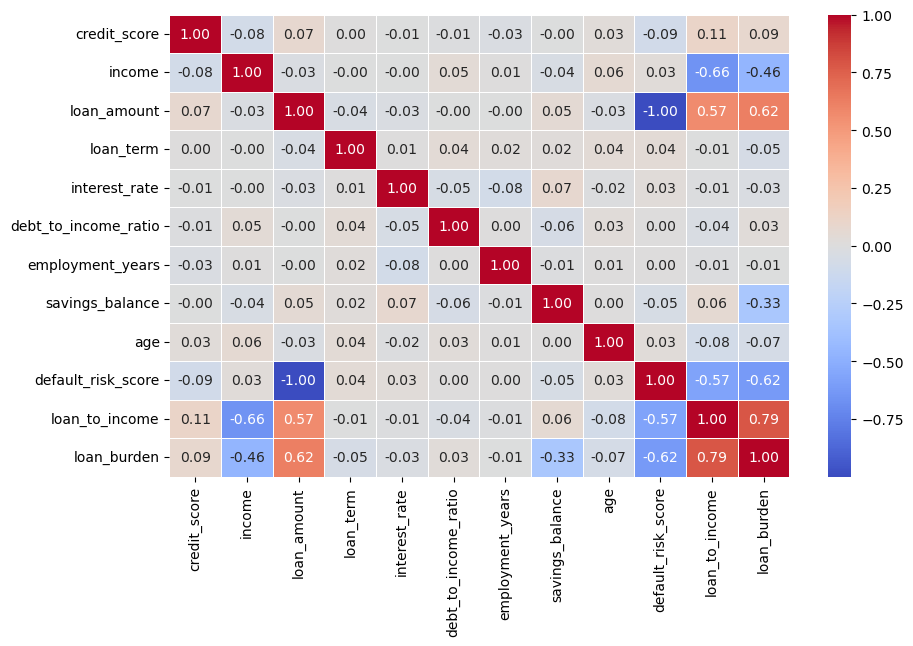

In [99]:
#Getting the correlation matrix
df_corr = df_train.drop(['age_group', 'credit_score_category'], axis =1)
corr_matrix = df_corr.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt = '.2f',linewidth=0.5)

Only loan_amount, lona burden loan_to_income have moderation/strong correlation. The other variables can be dropped.

Text(0, 0.5, 'Default risk score')

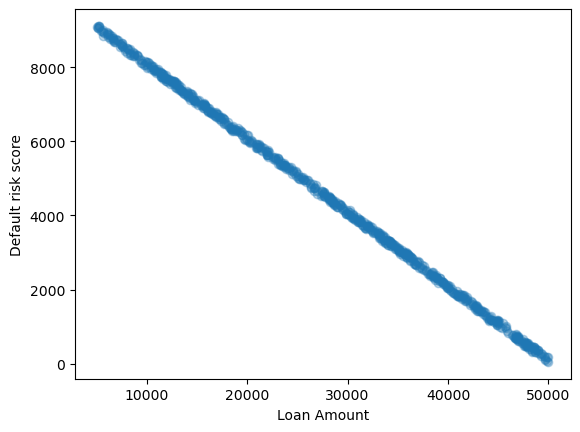

In [100]:
#Scatter plot of loan amount against default risk score
plt.scatter(df_train['loan_amount'], df_train['default_risk_score'], alpha = 0.3)
plt.xlabel('Loan Amount')
plt.ylabel('Default risk score')

### Insights
1. Borrowers with larger loans are more credit worthy
2. Stricter screening for large loans. High risk borrowers are less likely to get approved for large loans.
3. Small loans are often high risk for borrowers: they struggle with repayments.

### Loan to income and DRS correlation is -0.57
1. Borrowers with higher ratios tend to have lower default risk.
    * Explanation: if high income borrowers take larger loans, their loan to income ratio rises but their default rik remains low due to financial stability.
    Since lenders screen such applicants carefully, their actual default risk is lower.
    Some borrowers with low loan-to-income ratios may still default due to poor financial habits, multiple debts.

Text(0, 0.5, 'Default Risk Score')

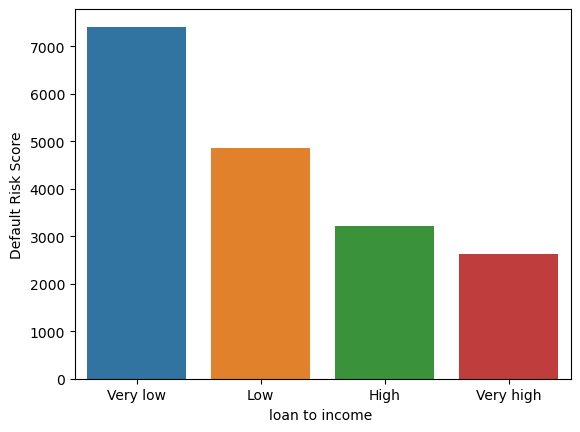

In [101]:
#Plotting loan_to_income(new feature) against default risk score 
loan_to_income_drs = df_train.groupby(pd.qcut(df_train['loan_to_income'], q=4, labels=['Very low', 'Low', 'High', 'Very high']))['default_risk_score'].mean().reset_index()

sns.barplot(x=loan_to_income_drs['loan_to_income'], y=loan_to_income_drs['default_risk_score'], data=df_train)
plt.xlabel('loan to income ')
plt.ylabel('Default Risk Score')


c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


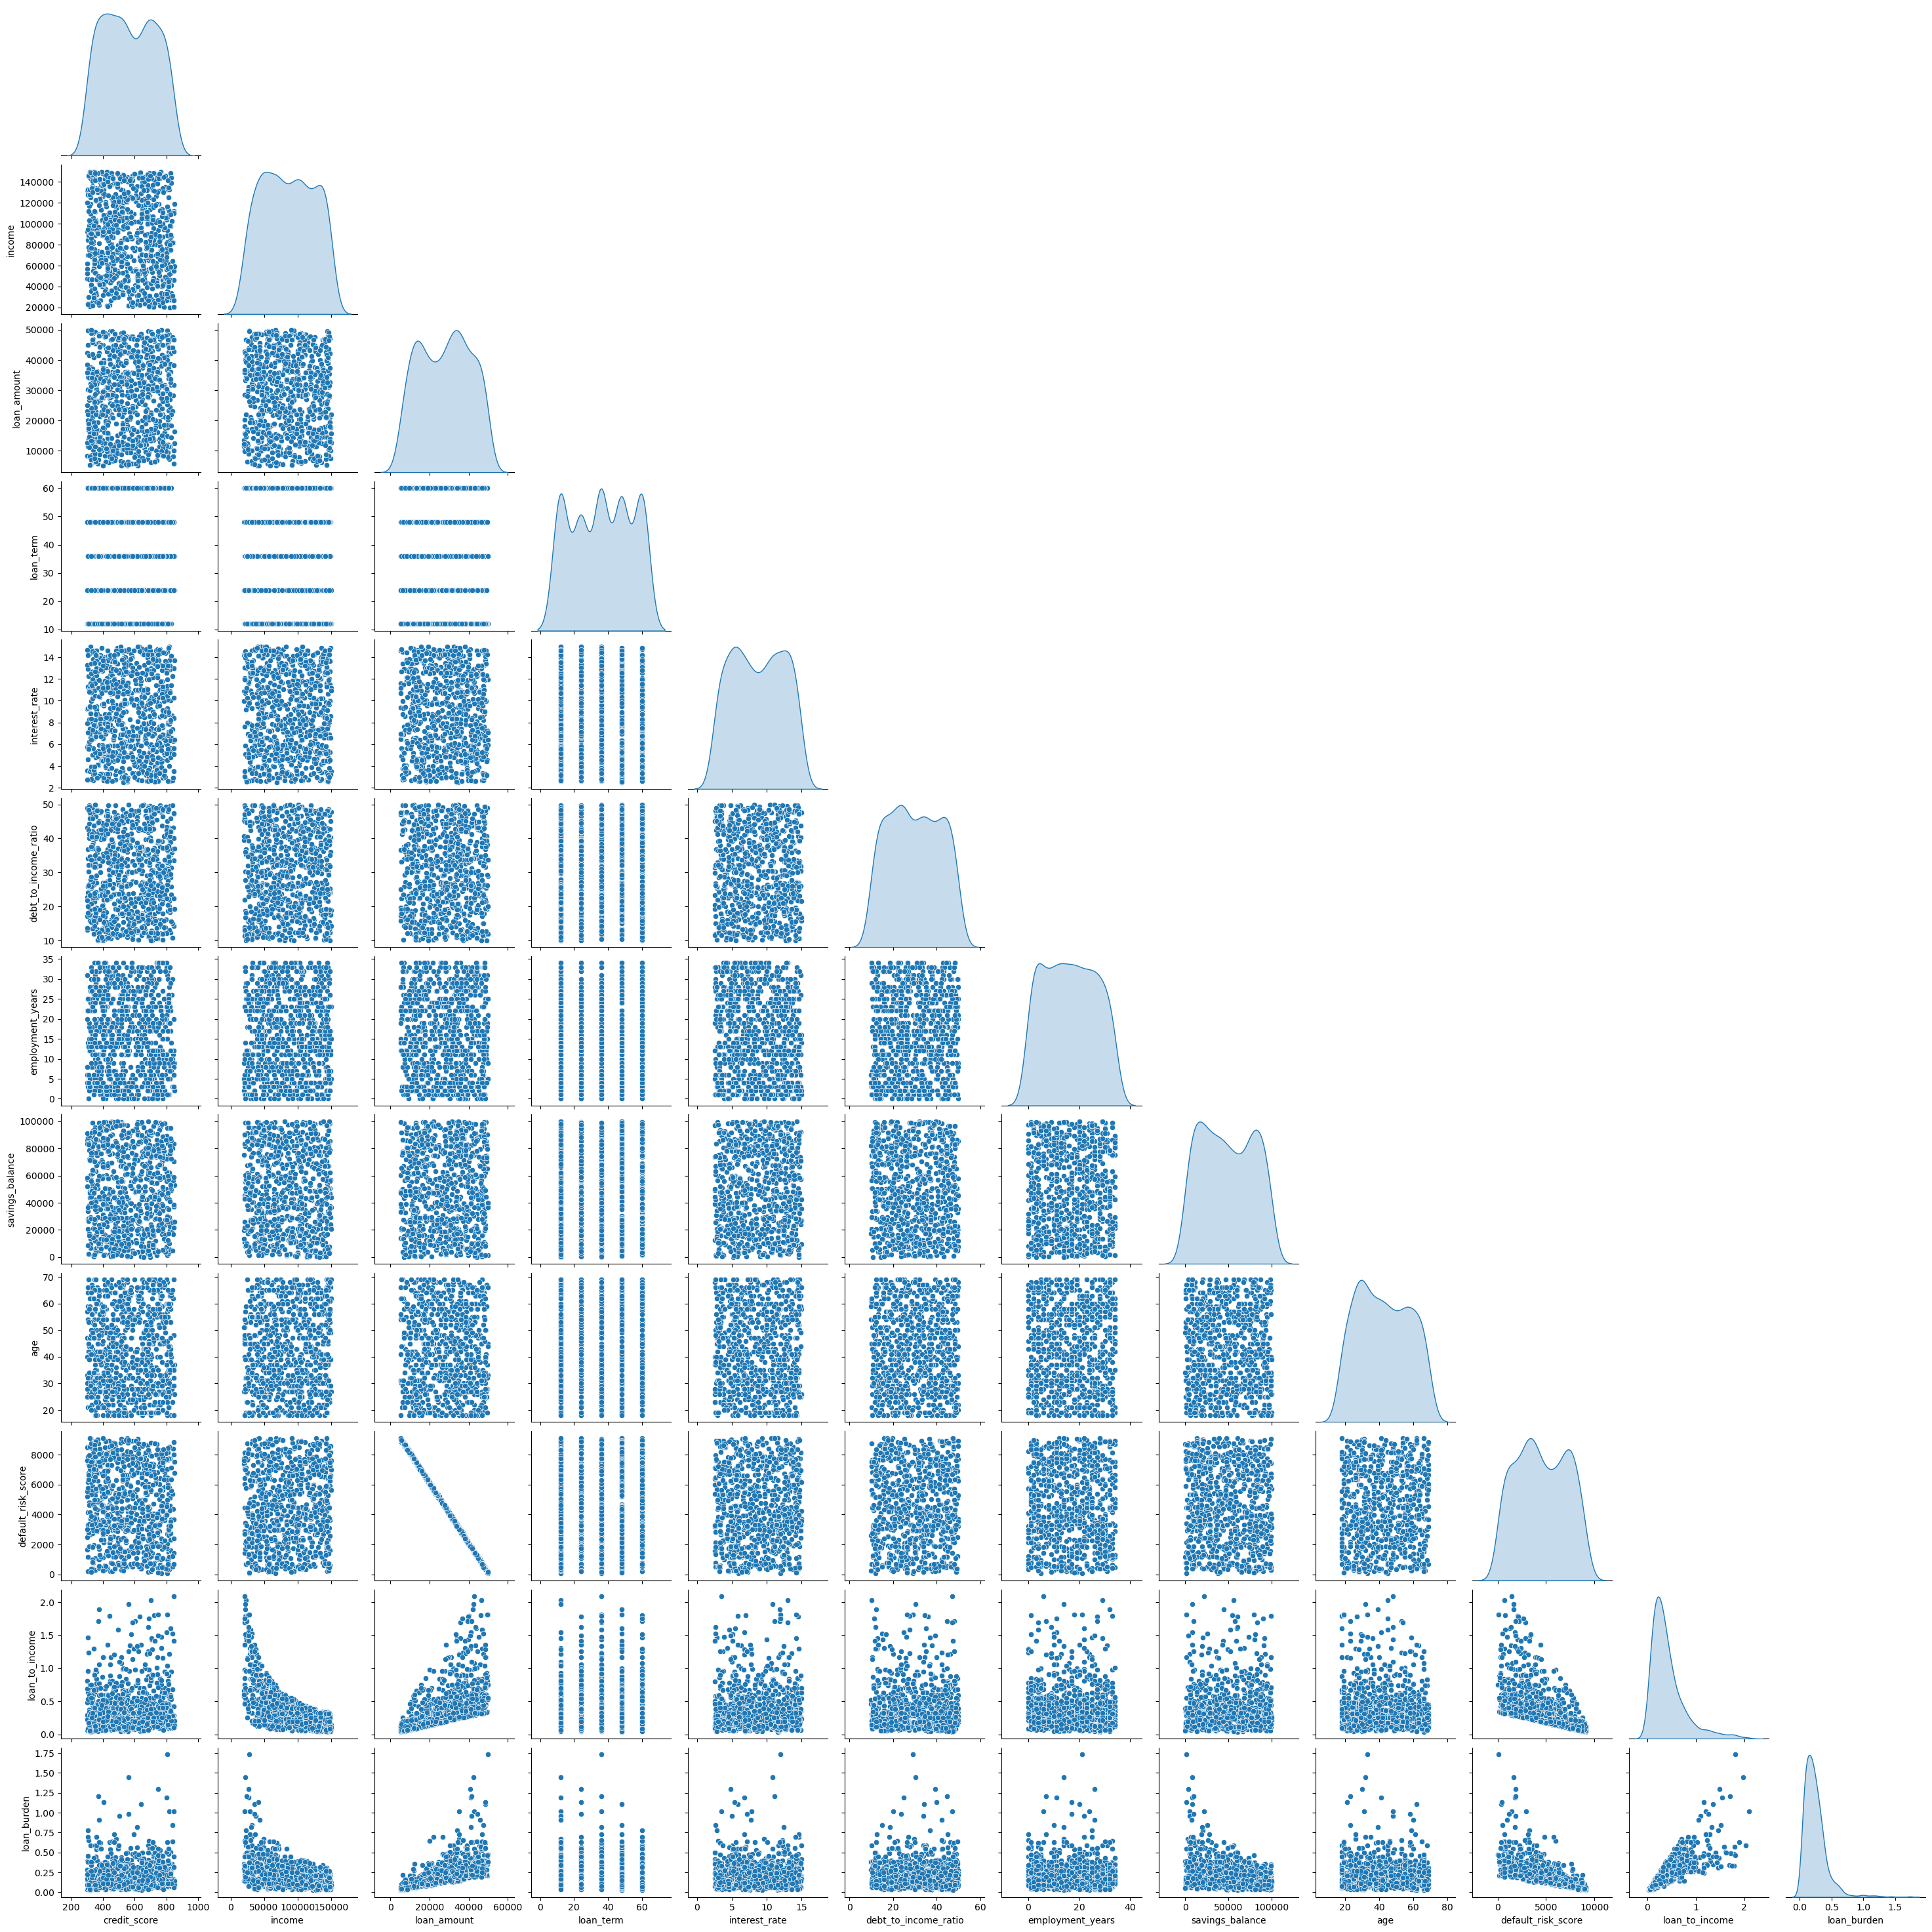

In [102]:
# Pairplot with hue for target variable
sns.pairplot(df_train, diag_kind='kde', corner=True)  # `corner=True` removes duplicate plots

# Show the plot
plt.show()

In [103]:
loan_to_income_drs

,loan_to_income,default_risk_score
0,Very low,7416.237079
1,Low,4852.639695
2,High,3217.841917
3,Very high,2633.156058


In [104]:
#Making a copy of the dataframe
df_copy = df_train.copy()

#Converting categorical varible into numeric
df_copy = pd.get_dummies(df_copy, columns=['credit_score_category'], drop_first=True)

#converting boolean to integer
df_copy[['credit_score_category_Medium', 'credit_score_category_High', 'credit_score_category_Very High']] = \
df_copy[['credit_score_category_Medium', 'credit_score_category_High', 'credit_score_category_Very High']].astype(int)


In [105]:
df_copy.head()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score,loan_to_income,age_group,loan_burden,credit_score_category_Medium,credit_score_category_High,credit_score_category_Very High
0,810,107410.0,11924.0,48,7.97,43.29,32,27181.0,58,7634.543366,0.111014,Retirees,0.088594,0,0,1
1,418,37482.0,19291.0,24,6.94,11.01,33,15089.0,43,6249.833059,0.514674,Pre retirement,0.366951,0,0,0
2,724,85641.0,39501.0,36,8.59,37.11,0,97459.0,33,2148.117990,0.461239,Middle aged,0.215735,0,0,1
3,444,73331.0,25714.0,36,13.09,33.39,18,2413.0,48,4979.385344,0.350657,Pre retirement,0.339486,1,0,0
4,440,46723.0,35651.0,36,8.30,46.21,6,9716.0,42,2993.851950,0.763029,Middle aged,0.631673,1,0,0


In [106]:
df_copy.columns

Index(['credit_score', 'income', 'loan_amount', 'loan_term', 'interest_rate',
       'debt_to_income_ratio', 'employment_years', 'savings_balance', 'age',
       'default_risk_score', 'loan_to_income', 'age_group', 'loan_burden',
       'credit_score_category_Medium', 'credit_score_category_High',
       'credit_score_category_Very High'],
      dtype='object')

In [107]:
# Performing anova test to evaluate if independent variables are statistically significant
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = """default_risk_score ~ credit_score + income + loan_amount + loan_term + 
             interest_rate + debt_to_income_ratio + employment_years + loan_burden +
             savings_balance + age + loan_to_income + C(age_group) +
             C(credit_score_category)"""
lm = smf.ols(formula, data=df_train).fit()
anova_results = sm.stats.anova_lm(lm, typ=2)
anova_results

,sum_sq,df,F,PR(>F)
C(age_group),1.501152e+02,3.0,4.507789e-01,7.168162e-01
C(credit_score_category),5.219408e+02,3.0,1.567329e+00,1.958813e-01
credit_score,1.312749e+05,1.0,1.182611e+03,1.373295e-158
income,4.369734e+01,1.0,3.936545e-01,5.305678e-01
loan_amount,1.894816e+09,1.0,1.706975e+07,0.000000e+00
loan_term,1.397421e+02,1.0,1.258889e+00,2.622058e-01
interest_rate,1.494962e+03,1.0,1.346761e+01,2.591912e-04
debt_to_income_ratio,1.605079e+04,1.0,1.445961e+02,1.109901e-30
employment_years,8.118493e+03,1.0,7.313675e+01,6.329164e-17
loan_burden,7.570705e+01,1.0,6.820192e-01,4.091442e-01


In [108]:
#Specifying variables to use for training the model
df_ln_train = pd.read_csv("train_data.csv")
df_ln_train['default_risk_score']= np.log(df_ln_train['default_risk_score'] + 1)

X_train= df_ln_train.drop(columns=['default_risk_score'])
y_train = df_ln_train['default_risk_score']


In [109]:
# Fit the OLS model
X = sm.add_constant(X_train)
model = sm.OLS(y_train, X).fit()

# Print the summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     default_risk_score   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     405.2
Date:                Tue, 18 Mar 2025   Prob (F-statistic):          5.20e-289
Time:                        02:51:40   Log-Likelihood:                -338.95
No. Observations:                 800   AIC:                             697.9
Df Residuals:                     790   BIC:                             744.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.7732 

In [110]:
df_ln_train.describe()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,565.405000,85779.287500,27795.651250,36.315000,8.732238,29.812500,16.376250,48850.921250,42.443750,8.152357
std,159.528109,37972.705711,12819.525021,17.163012,3.670453,11.626346,10.036339,29785.455545,15.011446,0.876490
min,300.000000,20060.000000,5097.000000,12.000000,2.510000,10.000000,0.000000,28.000000,18.000000,3.927068
25%,426.750000,53056.250000,16136.000000,24.000000,5.537500,19.925000,8.000000,21359.750000,29.000000,7.774264
50%,553.000000,85105.000000,28518.500000,36.000000,8.725000,29.645000,16.000000,47314.500000,42.000000,8.384956
75%,702.000000,118776.000000,38539.750000,48.000000,11.915000,40.005000,25.000000,76191.000000,55.250000,8.827912
max,849.000000,149972.000000,49976.000000,60.000000,14.990000,49.910000,34.000000,99976.000000,69.000000,9.117659


In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Adding a constant for VIF calculation
X_vif = sm.add_constant(X)

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Display VIF values
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,const,53.786900
5,interest_rate,1.015253
2,income,1.015175
1,credit_score,1.014323
8,savings_balance,1.012595
3,loan_amount,1.011773
6,debt_to_income_ratio,1.009519
9,age,1.008272
7,employment_years,1.007945
4,loan_term,1.005604


In [112]:
# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

<IPython.core.display.Javascript object>

In [113]:
# Standardize the Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
# Save the fitted scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [115]:
# Dimensionality Reduction with PCA (to preserve 95% of variance)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Number of PCA components selected:", pca.n_components_)

<IPython.core.display.Javascript object>

Number of PCA components selected: 9


In [116]:
# Save PCA model
with open("pca.pkl", "wb") as file:
    pickle.dump(pca, file)

print("PCA model saved successfully!")

PCA model saved successfully!


In [117]:
# Model Selection and Hyperparameter Tuning Using Ridge Regression
# Ridge (L2 regularization) can help control overfitting.
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(ridge, param_grid, cv=3, scoring='r2')  # Using 3-fold CV due to small data size
grid_search.fit(X_train_pca, y_train)
best_alpha = grid_search.best_params_['alpha']
print("Best alpha from grid search:", best_alpha)
# Train the final Ridge model with the best hyperparameter
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_pca, y_train)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best alpha from grid search: 10


<IPython.core.display.Javascript object>

Ridge(alpha=10)

In [118]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Make Predictions and Evaluate the Model
y_pred = best_ridge.predict(X_test_pca)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 0.10915026219128206
Mean Absolute Error: 0.27180928454082043
R-squared Score: 0.8191756611482897


In [127]:
import pickle

# Save the best Ridge model to a file
with open("best_ridge_model.pkl", "wb") as file:
    pickle.dump(best_ridge, file)

print("Best Ridge model saved successfully as best_ridge_model.pkl!")


Best Ridge model saved successfully as best_ridge_model.pkl!


In [120]:
df = pd.read_csv("test.csv")

In [121]:
df['default_risk_score'] = np.log(df['default_risk_score'] + 1)
X =df.drop(columns=['default_risk_score'])
y = df['default_risk_score']

In [122]:
import pickle

# Load the model from the .pkl file
with open('best_ridge_model.pkl', 'rb') as file:
    model = pickle.load(file)

In [123]:
# Load the saved scaler
with open("scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X)  # Correct way to scale test data


In [124]:
# Load saved PCA model
with open("pca.pkl", "rb") as file:
    pca = pickle.load(file)

# Transform test data
X_test_pca = pca.transform(X_test_scaled)  # Ensure test data is scaled
print("PCA transformation successful!")


PCA transformation successful!


In [128]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_pred = model.predict(X_test_pca)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 0.1876037952678507
Mean Absolute Error: 0.28402480358730114
R-squared Score: 0.7565342556894414


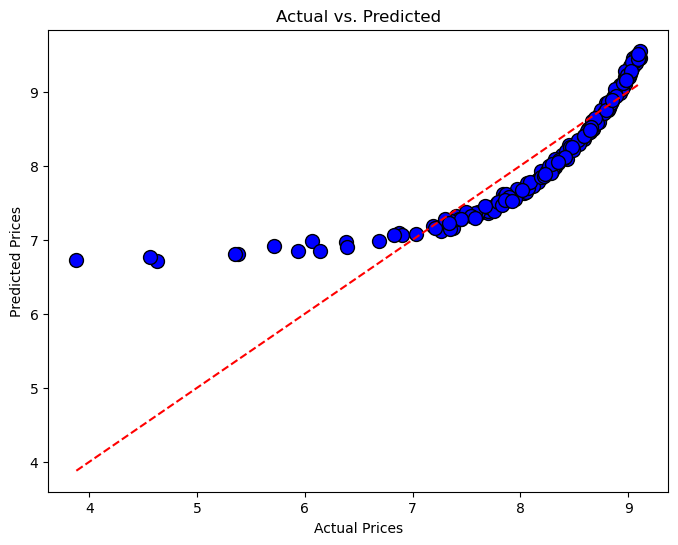

In [129]:
# Visualize Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', edgecolors='k', s=100)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted")
# Plot a diagonal line for reference (perfect predictions)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
plt.show()

In [130]:
y_pred

array([9.34689937, 7.28566382, 9.43579561, 8.64744927, 8.00562883,
       9.19482696, 7.40276563, 8.30717428, 7.83452095, 7.97974116,
       7.551115  , 7.79498961, 8.73542093, 6.97789167, 8.93758183,
       8.83155252, 8.37263614, 9.06373425, 7.62117802, 9.2381698 ,
       8.66186917, 8.49808591, 8.13839709, 8.22147073, 8.97708425,
       7.56216294, 9.34614875, 8.47219238, 7.26256676, 8.82290834,
       8.3594488 , 7.36609523, 8.06901011, 8.14702789, 7.58397217,
       7.57911987, 8.57577957, 7.63111493, 8.33124085, 7.32792317,
       8.107799  , 8.73657543, 9.05798423, 9.10036202, 7.39330551,
       8.40670047, 6.70596613, 8.61553927, 8.29386389, 9.20227349,
       9.32655256, 7.52768821, 6.97633045, 8.51199652, 7.11732549,
       7.85329466, 8.03158732, 7.16274312, 9.36577701, 8.84569389,
       8.7815529 , 7.92569597, 8.89929004, 8.75285817, 8.78066252,
       7.44455435, 6.91786864, 8.28209907, 8.820696  , 7.32049852,
       6.80316665, 9.22772957, 8.45945251, 8.66171417, 7.98987

In [ ]:
#Adding the predicted values to the test dataframe
df['Predicted_test_data'] = y_pred

In [132]:
df.head()

,credit_score,income,loan_amount,loan_term,interest_rate,debt_to_income_ratio,employment_years,savings_balance,age,default_risk_score,Predicted_test_data
0,340,31745,8983,48,10.12,18.33,11,91417,56,9.029292,9.346899
1,439,115081,42051,60,3.33,31.77,6,17127,51,7.445005,7.285664
2,619,35313,6619,36,9.06,24.29,20,46761,42,9.076309,9.435796
3,664,72269,19226,48,4.29,12.50,26,64340,36,8.731138,8.647449
4,564,46292,30476,48,11.15,40.55,20,93831,50,8.291978,8.005629
